In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                            mean_squared_error, mean_absolute_error, r2_score,
                            precision_score, recall_score, f1_score, ConfusionMatrixDisplay)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../Data/StudentDataset.csv")

In [4]:
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [5]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   academic_level        5000 non-null   str    
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality      5000 non-n

In [7]:
df.drop(columns=['student_id'], inplace=True)

In [8]:
hour_cols = ['study_hours', 'self_study_hours', 'online_classes_hours',
             'social_media_hours', 'gaming_hours', 'sleep_hours',
             'screen_time_hours', 'exercise_minutes']

for col in hour_cols:
    df[col] = df[col].clip(lower=0)

score_cols = ['mental_health_score', 'focus_index', 'burnout_level',
              'productivity_score', 'exam_score']

for col in score_cols:
    df[col] = df[col].clip(lower=0, upper=100)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.reset_index(drop=True, inplace=True)
df.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [9]:
df['total_active_hours'] = df['study_hours'] + df['self_study_hours'] + df['online_classes_hours']
df['total_distraction_hours'] = df['social_media_hours'] + df['gaming_hours']
df['study_distraction_ratio'] = df['study_hours'] / (df['total_distraction_hours'].replace(0, 0.1))
df['healthy_sleep'] = df['sleep_hours'].apply(lambda x: 1 if 7 <= x <= 9 else 0)

df['wellness_score'] = (
    df['mental_health_score'] * 0.4 +
    df['sleep_hours'] * 0.3 +
    (df['exercise_minutes'] / 60) * 0.3
)

df['stress_index'] = (
    df['burnout_level'] * 0.5 +
    df['screen_time_hours'] * 0.3 +
    (10 - df['sleep_hours']) * 0.2
)

df['pass_fail'] = df['exam_score'].apply(lambda x: 1 if x >= 40 else 0)
df.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,...,burnout_level,productivity_score,exam_score,total_active_hours,total_distraction_hours,study_distraction_ratio,healthy_sleep,wellness_score,stress_index,pass_fail
0,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,...,31.77,73.65,50.16,11.40,5.24,1.458015,0,6.361,18.522,1
1,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,...,37.00,13.70,1.00,6.53,4.20,0.526190,0,3.546,21.121,0
2,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,...,34.37,45.15,18.30,3.74,3.42,1.008772,1,6.057,19.793,0
3,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,...,77.31,20.92,9.37,10.84,4.47,1.286353,0,3.658,42.894,0
4,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,...,39.53,59.23,27.81,11.88,3.35,2.038806,1,6.208,23.169,0


In [10]:
le = LabelEncoder()
categorical_cols = ['gender', 'academic_level', 'internet_quality']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

TARGET_CLASS = 'pass_fail'
TARGET_REG = 'exam_score'

X = df.drop(columns=[TARGET_CLASS, TARGET_REG])
y_class = df[TARGET_CLASS]
y_reg = df[TARGET_REG]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [11]:
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_class, y_reg, test_size=0.2, random_state=42
)

Accuracy: 97.10%
              precision    recall  f1-score   support

        Fail       0.98      0.99      0.99       963
        Pass       0.67      0.43      0.52        37

    accuracy                           0.97      1000
   macro avg       0.82      0.71      0.75      1000
weighted avg       0.97      0.97      0.97      1000



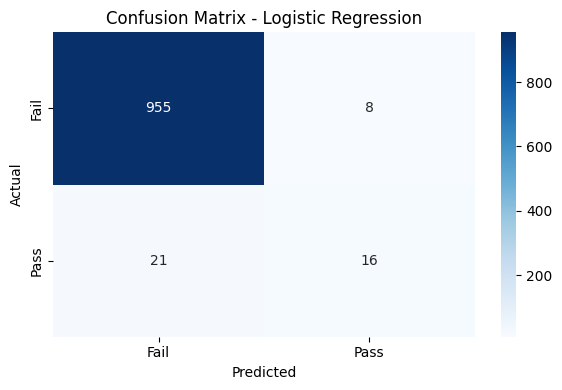

In [12]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train_class)

y_pred_class = log_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class) * 100:.2f}%")
print(classification_report(y_test_class, y_pred_class, target_names=['Fail', 'Pass']))

cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

MAE: 3.97
RMSE: 5.00
R2 Score: 0.8164


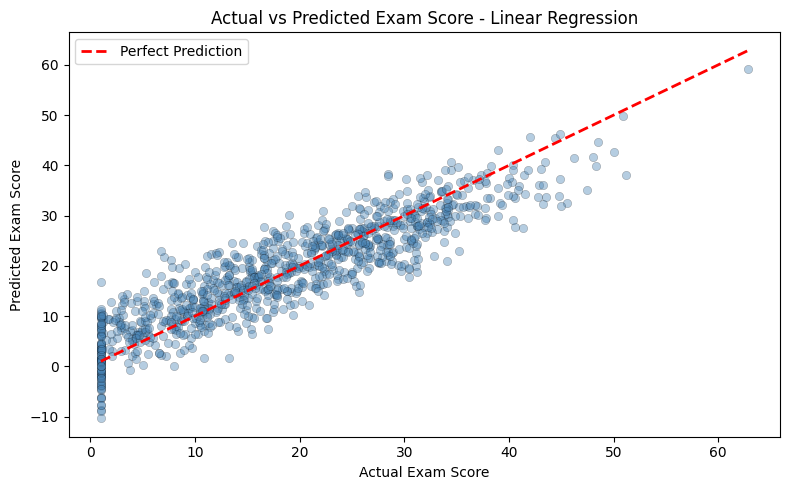

In [13]:
reg_model = LinearRegression()
reg_model.fit(X_train, y_train_reg)

y_pred_reg = reg_model.predict(X_test)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Score - Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

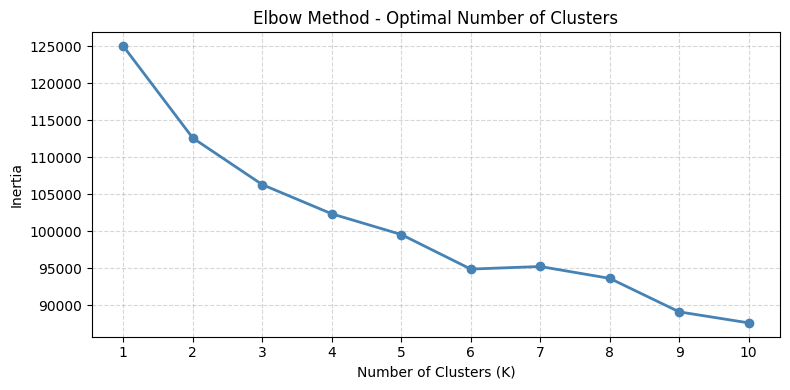

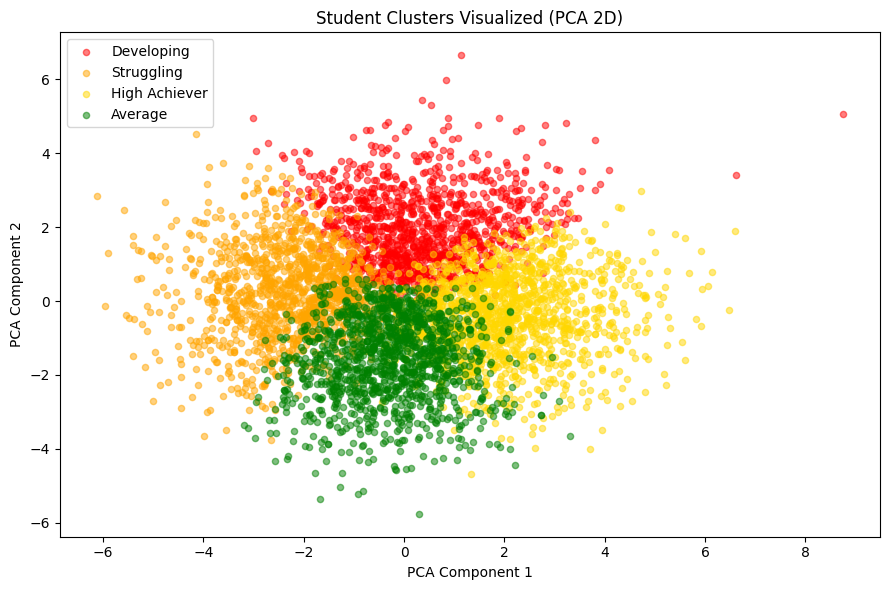

In [14]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = df.groupby('cluster')['exam_score'].mean().sort_values()
labels = ['Struggling', 'Average', 'Developing', 'High Achiever']
cluster_label_map = {cluster: label for cluster, label in zip(cluster_means.index, labels)}
df['learner_type'] = df['cluster'].map(cluster_label_map)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['red', 'orange', 'gold', 'green']
for i in range(K):
    mask = df['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cluster_label_map[i], alpha=0.5, s=20, color=colors[i])

plt.title('Student Clusters Visualized (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

Accuracy: 97.10%
Precision: 66.67%
Recall: 43.24%
F1 Score: 52.46%


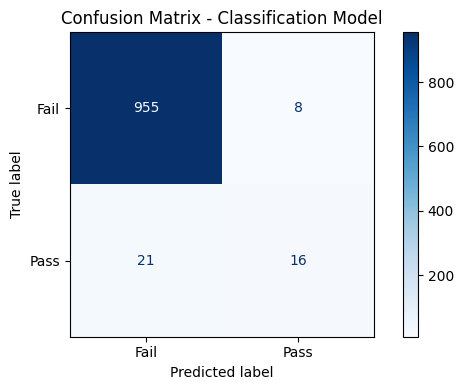

MAE: 3.97
RMSE: 5.00
R2 Score: 0.8164


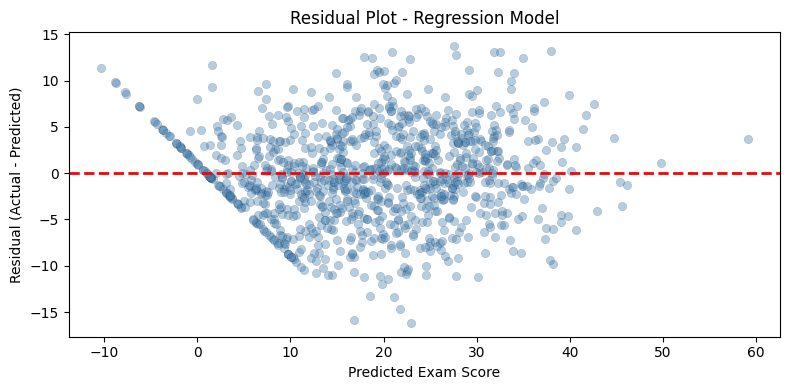

In [15]:
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test_class, y_pred_class, display_labels=['Fail', 'Pass'], cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Classification Model')
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(y_test_reg - y_pred_reg))
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

residuals = y_test_reg.values - y_pred_reg
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_reg, residuals, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.2)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot - Regression Model')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

In [16]:
def generate_recommendations(student):
    tips = []
    score = student['exam_score']

    if score < 20:
        tips.append("CRITICAL: Your predicted score is very low. Consider speaking with your teacher or academic advisor immediately.")
        tips.append("Start with the basics and review foundational concepts before moving forward.")
    elif score < 40:
        tips.append("WARNING: You are at risk of failing. Increase your daily study hours significantly.")
        tips.append("Create a structured weekly study timetable and stick to it.")
    elif score < 60:
        tips.append("AVERAGE: You are passing but there is clear room for improvement.")
        tips.append("Focus on your weakest topics and practice with past exam papers.")
    else:
        tips.append("GREAT: You are performing well. Keep up the consistency.")
        tips.append("Challenge yourself with advanced problems to push your score higher.")

    if student['study_hours'] < 2:
        tips.append("STUDY TIME: You are studying less than 2 hours/day. Aim for at least 4-5 hours for meaningful progress.")
    elif student['study_hours'] < 4:
        tips.append("STUDY TIME: Try to increase study hours to 5-6 hours/day for better retention.")

    if student['sleep_hours'] < 6:
        tips.append("SLEEP: You are sleeping less than 6 hours. Poor sleep severely impacts memory and focus. Aim for 7-8 hours.")
    elif student['sleep_hours'] > 9:
        tips.append("SLEEP: You may be oversleeping. Too much sleep can reduce motivation. 7-8 hours is ideal.")

    if student['total_distraction_hours'] > 4:
        tips.append("DISTRACTIONS: You are spending 4+ hours on social media/gaming. Try using app blockers during study sessions.")
    elif student['total_distraction_hours'] > 2:
        tips.append("DISTRACTIONS: Reduce social media and gaming to under 2 hours/day to free up valuable study time.")

    if student['mental_health_score'] <= 3:
        tips.append("MENTAL HEALTH: Your mental health score is low. Consider talking to a counselor and taking short mindfulness breaks.")
    elif student['mental_health_score'] <= 6:
        tips.append("MENTAL HEALTH: Take regular breaks using the Pomodoro technique (25 min study, 5 min break) to avoid burnout.")

    if student['burnout_level'] > 70:
        tips.append("BURNOUT: Your burnout level is very high. Take a short rest day and avoid cramming sessions.")
    elif student['burnout_level'] > 50:
        tips.append("BURNOUT: Moderate burnout detected. Space out your study sessions and include enjoyable activities.")

    if student['exercise_minutes'] < 20:
        tips.append("EXERCISE: You are exercising less than 20 minutes/day. Even a 30-minute walk improves memory and concentration.")

    if student['internet_quality'] == 0:
        tips.append("INTERNET: Poor internet quality detected. Download study materials in advance or use offline resources.")

    learner = student['learner_type']

    if 'Struggling' in learner:
        tips.append("LEARNER TYPE - Struggling: Join a study group or find a tutor. Peer learning can significantly boost your understanding.")
    elif 'Average' in learner:
        tips.append("LEARNER TYPE - Average: You have potential. Set small daily goals and track your weekly progress.")
    elif 'Developing' in learner:
        tips.append("LEARNER TYPE - Developing: You are on the right track. Focus on consistency and avoid skipping study days.")
    elif 'High Achiever' in learner:
        tips.append("LEARNER TYPE - High Achiever: Excellent work. Consider mentoring peers as teaching is the best way to master content.")

    return tips

df['recommendations'] = df.apply(lambda row: generate_recommendations(row), axis=1)
df['num_recommendations'] = df['recommendations'].apply(len)

In [17]:
mock_student_input = {
    'age': 20,
    'gender': 'Male',
    'academic_level': 'Undergraduate',
    'study_hours': 2.5,
    'self_study_hours': 1.0,
    'online_classes_hours': 1.5,
    'social_media_hours': 4.0,
    'gaming_hours': 2.5,
    'sleep_hours': 5.5,
    'screen_time_hours': 8.0,
    'exercise_minutes': 15,
    'caffeine_intake_mg': 200,
    'part_time_job': 1,
    'upcoming_deadline': 1,
    'internet_quality': 'Poor',
    'mental_health_score': 4,
    'focus_index': 35.0,
    'burnout_level': 65.0,
    'productivity_score': 30.0,
}

mock_df = pd.DataFrame([mock_student_input])
mock_df['total_active_hours'] = mock_df['study_hours'] + mock_df['self_study_hours'] + mock_df['online_classes_hours']
mock_df['total_distraction_hours'] = mock_df['social_media_hours'] + mock_df['gaming_hours']
mock_df['study_distraction_ratio'] = mock_df['study_hours'] / mock_df['total_distraction_hours'].replace(0, 0.1)
mock_df['healthy_sleep'] = mock_df['sleep_hours'].apply(lambda x: 1 if 7 <= x <= 9 else 0)
mock_df['wellness_score'] = mock_df['mental_health_score'] * 0.4 + mock_df['sleep_hours'] * 0.3 + (mock_df['exercise_minutes'] / 60) * 0.3
mock_df['stress_index'] = mock_df['burnout_level'] * 0.5 + mock_df['screen_time_hours'] * 0.3 + (10 - mock_df['sleep_hours']) * 0.2

gender_map = {'Male': 1, 'Female': 0, 'Other': 2}
level_map = {'High School': 0, 'Undergraduate': 1}
internet_map = {'Good': 1, 'Poor': 0}

mock_df['gender'] = mock_df['gender'].map(gender_map)
mock_df['academic_level'] = mock_df['academic_level'].map(level_map)
mock_df['internet_quality'] = mock_df['internet_quality'].map(internet_map)
mock_df = mock_df[X.columns]

mock_scaled = scaler.transform(mock_df)

pred_class = log_model.predict(mock_scaled)[0]
pred_proba = log_model.predict_proba(mock_scaled)[0]
pred_score = reg_model.predict(mock_scaled)[0]
pred_score = float(np.clip(pred_score, 0, 100))
pred_cluster = kmeans.predict(mock_scaled)[0]
pred_learner_type = cluster_label_map[pred_cluster]

mock_student_full = mock_student_input.copy()
mock_student_full['exam_score'] = pred_score
mock_student_full['total_active_hours'] = mock_df['total_active_hours'].values[0]
mock_student_full['total_distraction_hours'] = mock_df['total_distraction_hours'].values[0]
mock_student_full['study_distraction_ratio'] = mock_df['study_distraction_ratio'].values[0]
mock_student_full['healthy_sleep'] = mock_df['healthy_sleep'].values[0]
mock_student_full['wellness_score'] = mock_df['wellness_score'].values[0]
mock_student_full['stress_index'] = mock_df['stress_index'].values[0]
mock_student_full['internet_quality'] = 0 if mock_student_input['internet_quality'] == 'Poor' else 1
mock_student_full['learner_type'] = pred_learner_type

mock_series = pd.Series(mock_student_full)
recs = generate_recommendations(mock_series)

print(f"Predicted Exam Score: {pred_score:.2f}")
print(f"Pass/Fail: {'PASS' if pred_class == 1 else 'FAIL'}")
print(f"Pass Probability: {pred_proba[1]*100:.1f}%")
print(f"Learner Type: {pred_learner_type}")
print(f"\nRecommendations:")
for i, tip in enumerate(recs, 1):
    print(f"{i}. {tip}")

Predicted Exam Score: 13.53
Pass/Fail: FAIL
Pass Probability: 0.0%
Learner Type: Struggling

Recommendations:
1. CRITICAL: Your predicted score is very low. Consider speaking with your teacher or academic advisor immediately.
2. Start with the basics and review foundational concepts before moving forward.
3. STUDY TIME: Try to increase study hours to 5-6 hours/day for better retention.
4. SLEEP: You are sleeping less than 6 hours. Poor sleep severely impacts memory and focus. Aim for 7-8 hours.
5. DISTRACTIONS: You are spending 4+ hours on social media/gaming. Try using app blockers during study sessions.
6. MENTAL HEALTH: Take regular breaks using the Pomodoro technique (25 min study, 5 min break) to avoid burnout.
7. BURNOUT: Moderate burnout detected. Space out your study sessions and include enjoyable activities.
8. EXERCISE: You are exercising less than 20 minutes/day. Even a 30-minute walk improves memory and concentration.
9. INTERNET: Poor internet quality detected. Download st

In [18]:
os.makedirs("student_ml_app", exist_ok=True)

joblib.dump(log_model, "student_ml_app/classification_model.pkl")
joblib.dump(reg_model, "student_ml_app/regression_model.pkl")
joblib.dump(kmeans, "student_ml_app/clustering_model.pkl")
joblib.dump(scaler, "student_ml_app/scaler.pkl")
joblib.dump(list(X.columns), "student_ml_app/feature_columns.pkl")
joblib.dump(cluster_label_map, "student_ml_app/cluster_label_map.pkl")

['student_ml_app/cluster_label_map.pkl']